In [ ]:
# Early Stopping is a regularization technique used to prevent overfitting in machine learning and deep learning.

In [ ]:
# How it works
# During training, the training loss keeps decreasing.
# But after some epochs, the validation loss starts increasing, meaning the model is memorizing the training data and not generalizing well.
# Early stopping stops the training automatically when the validation performance stops improving.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import tensorflow
import keras
from keras import Sequential
from keras.layers import Dense
from keras.callbacks import  EarlyStopping
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_circles


In [2]:
# Make a synthetic binary clas dataset
X,y=make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

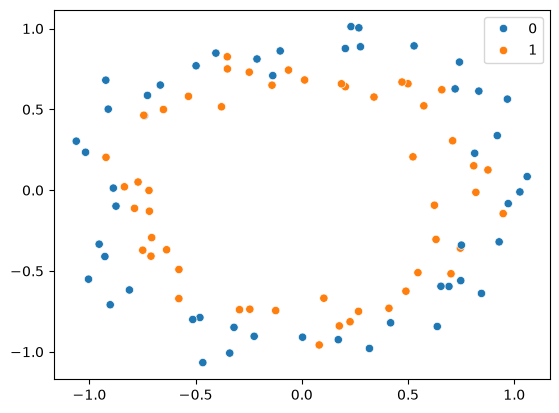

In [6]:
# Make a scatter plot
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [7]:
# Split the dataset
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

# Early Stoping

In [8]:
# Create model objective
model=Sequential()
model.add(Dense(256, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

In [9]:
# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
# Create callback object
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [12]:
# Train the model
history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5000, callbacks=callback)

Epoch 1/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.4625 - loss: 0.6975 - val_accuracy: 0.6000 - val_loss: 0.6935
Epoch 2/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4750 - loss: 0.6936 - val_accuracy: 0.4000 - val_loss: 0.7007
Epoch 3/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5250 - loss: 0.6897 - val_accuracy: 0.3500 - val_loss: 0.7058
Epoch 4/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5375 - loss: 0.6879 - val_accuracy: 0.3500 - val_loss: 0.7111
Epoch 5/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5375 - loss: 0.6859 - val_accuracy: 0.3500 - val_loss: 0.7153
Epoch 6/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5375 - loss: 0.6840 - val_accuracy: 0.3500 - val_loss: 0.7183
Epoch 7/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5375 - loss: 0.6828 - val_accuracy: 0.3500 - val_loss: 0.7222
Epoch 8/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5375 - loss: 0.6817 - val_accuracy: 0.3500 - 

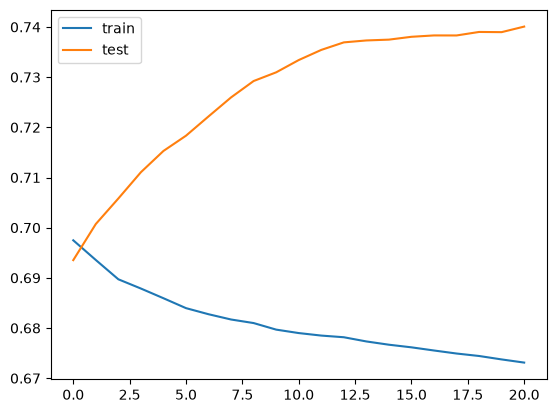

In [13]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()